In [ ]:
import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) =\
keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

딥러닝을 위한 Keras,
데이터를 나누는 train_test_split을 사용하기 위해 불러
사람 옷(티셔츠, 신발 등) 이미지로 이루어진 Fashion-MNIST 데이터를
훈련용과 테스트용으로 나누어 불러오기
이미지 크기는 그대로 28×28이지만,
뒤에 채널(1)을 추가해 CNN이 학습할 수 있도록 형태를 바꿈
/ 255.0을 해서 픽셀 값을 0~1 범위로 정규화함으로 성능과 속도 향상
전체 훈련 데이터 중 20%는 검증용
검증 데이터는 모델이 얼마나 잘 학습하고 있는지 평가하는 데 사용

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                              padding='same'))

층을 위에서 아래로 차례대로 쌓는 방식(Sequential 모델)**을 사용
모델에 들어오는 이미지의 크기를 정함

가로 28

세로 28

채널 1(흑백)
32개의 필터(커널) 를 사용하겠다는 의미
필터 크기가 3×3이라는 의미
필터가 찾은 값을 더 잘 구분되도록 만드는 함수
출력되는 특징 맵(feature map)의 크기를
입력 이미지와 동일하게 유지

In [ ]:
model.add(keras.layers.MaxPooling2D(2))

이 층은 이미지 크기를 절반으로 줄여주는 역할

In [ ]:
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu',
                              padding='same'))
model.add(keras.layers.MaxPooling2D(2))

64개의 필터
kernel_size=3: 3×3 크기의 작은 필터로 이미지를 스캔
activation='relu':중요한 특징은 살리고, 불필요한 값은 0으로 만들어 학습을 돕는 함수
padding='same':출력의 가로·세로 크기가 입력과 같음;

MaxPooling2D(2):이 층은 이미지 크기를 다시 한 번 절반으로 줄이는 단계

In [ ]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

Flatten():

CNN에서 나온 **2D 형태의 특징 맵(feature map)**을 1차원 벡터로 일렬로 펴주는 역할
완전연결층(FC layer), 뉴런 100개

완전연결층(FC layer), 뉴런 100개

Flatten된 정보를 이용해
이미지가 어떤 옷인지 판단하는 데 필요한 패턴을 학습합니다.

relu
→ 중요한 정보만 살리고 학습을 빠르게 함

학습할 때 뉴런 중 40%를 랜덤하게 꺼서
특정 뉴런이 너무 많이 의존되지 않도록 함(과적합 방지)

출력층 (클래스 10개)

Fashion-MNIST는 10가지 옷 종류를 분류함

softmax는
→ 각 클래스가 정답일 확률을 계산


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

층(Layer) 구조

Conv2D

MaxPooling

Flatten

Dense

Dropout
등 모델에 쌓아 놓은 모든 층이 어떤 순서로 있는지 나타냄

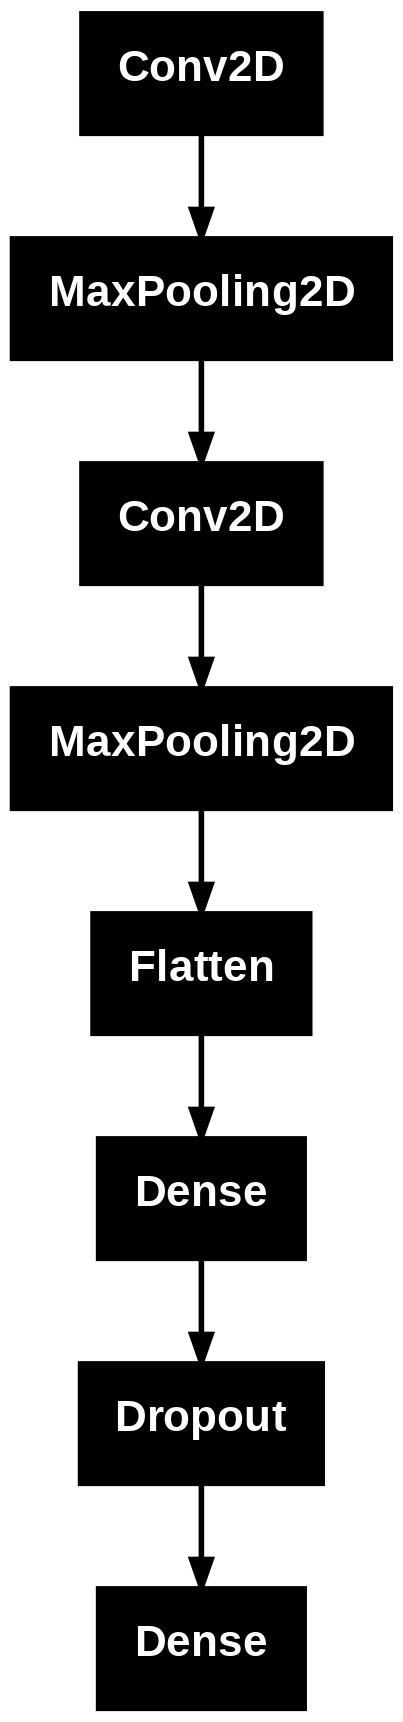

In [ ]:
keras.utils.plot_model(model)

모델 구조를 그림(다이어그램)으로 만들어주는 함수


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 101s 66ms/step - accuracy: 0.7385 - loss: 0.7289 - val_accuracy: 0.8739 - val_loss: 0.3392
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 121s 52ms/step - accuracy: 0.8728 - loss: 0.3600 - val_accuracy: 0.8958 - val_loss: 0.2870
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.8897 - loss: 0.3040 - val_accuracy: 0.9057 - val_loss: 0.2548
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 72s 48ms/step - accuracy: 0.9049 - loss: 0.2700 - val_accuracy: 0.9156 - val_loss: 0.2396
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 73s 49ms/step - accuracy: 0.9120 - loss: 0.2424 - val_accuracy: 0.9155 - val_loss: 0.2308
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 72s 48ms/step - accuracy: 0.9216 - loss: 0.2211 - val_accuracy: 0.9180 - val_loss: 0.2332
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 72s 48ms/step - accuracy: 0.9312 - loss: 0.1934 - val_accuracy: 0.9231 - val_loss: 0.2181
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 86s 51ms/step - accuracy: 0.9348

optimizer='adam'
→ 모델이 학습하면서 가중치를 효율적으로 업데이트하도록 도와주는 방법

loss='sparse_categorical_crossentropy'
→ 다중 클래스 분류 문제에서 모델이 얼마나 틀렸는지 계산하는 손실 함수

metrics=['accuracy']
→ 학습 과정에서 **정확도(accuracy)**를 모니터링

학습 중 검증 정확도가 가장 좋을 때만 모델을 저장

파일 이름: 'best-cnn-model.keras'
patience=2
→ 검증 성능이 2회 연속 좋아지지 않으면 학습 중단

restore_best_weights=True
→ 학습 중 가장 성능이 좋았던 가중치를 자동으로 불러옴
train_scaled, train_target → 학습 데이터

epochs=20 → 최대 20회 반복 학습

validation_data=(val_scaled, val_target) → 검증 데이터로 학습 중 성능 확인

callbacks=[...] → 체크포인트 + 얼리 스토핑 적용
history 객체에 훈련 손실, 검증 손실, 정확도 등 모든 기록이 저장됨

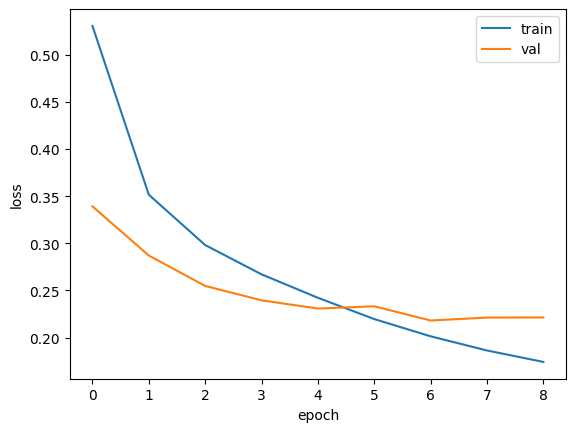

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

학습 과정 시각화

history.history['loss'] → 훈련 데이터의 손실값

history.history['val_loss'] → 검증 데이터의 손실값

plt.plot()

label='train' → 훈련 손실 그래프

label='val' → 검증 손실 그래프

x축 → 학습 반복 횟수(에폭)

y축 → 손실값(loss)

그래프에 train / val 구분 표시

In [ ]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9258 - loss: 0.2092


[0.2181118130683899, 0.9230833053588867]

학습이 끝난 모델을 검증 데이터로 테스트

손실값(loss)

정확도(accuracy)
두 가지를 반환

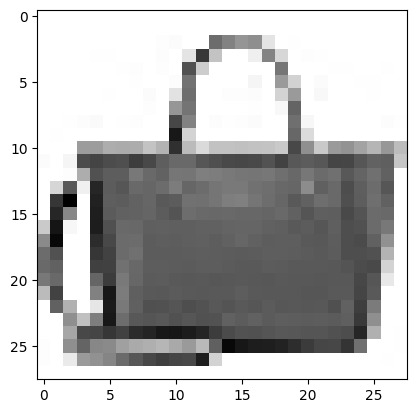

In [ ]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()

val_scaled[0]

검증 데이터에서 첫 번째 이미지를 선택

.reshape(28, 28)

CNN 학습을 위해 4차원 (28,28,1)로 바뀐 이미지를

원래 28×28 형태로 되돌림
➡ 이미지를 화면에 보여주기 위해 형태 복원

cmap='gray_r'

흑백 이미지를 표시

_r은 색을 반전(reverse) 시켜 검은색 배경에 흰색 옷을 표시

plt.show()

실제로 이미지를 화면에 출력

In [ ]:
preds = model.predict(val_scaled[0:1])
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
[[4.3355799e-20 2.0310437e-22 8.8204234e-24 4.7884481e-18 2.2780325e-20
  1.0137730e-16 1.0789694e-18 3.5530450e-19 1.0000000e+00 5.3177782e-21]]


model.predict(val_scaled[0:1])

검증 데이터에서 첫 번째 이미지를 선택 (0:1 → 1개 이미지)

학습된 CNN 모델로 예측 수행

출력은 각 클래스(옷 종류)에 대한 확률값 배열

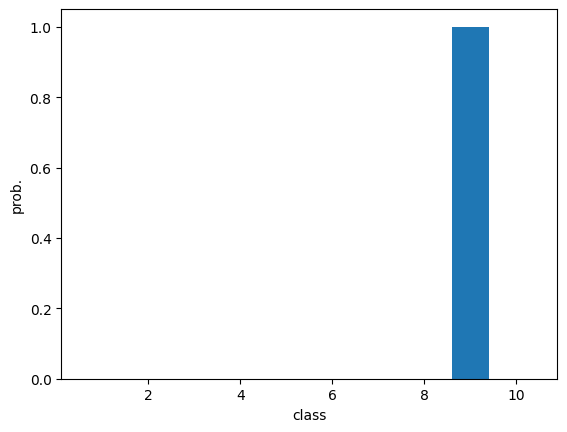

In [ ]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

plt.bar(range(1, 11), preds[0])

preds[0] → 모델이 예측한 첫 번째 이미지의 클래스별 확률

range(1, 11) → x축에 1~10 클래스 번호 표시

막대그래프(bar chart)로 확률 시각화

plt.xlabel('class'), plt.ylabel('prob.')

x축 → 클래스 번호 (0~9, 옷 종류)

y축 → 각 클래스일 확률(probability)

plt.show()

실제로 그래프를 화면에 출력

가장 높은 막대 → 모델이 예측한 옷 종류

In [ ]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈',
           '가방', '앵클부츠']


In [ ]:
import numpy as np
print(classes[np.argmax(preds)])

가방


np.argmax(preds)

preds → 모델이 예측한 각 클래스 확률 배열

argmax() → 가장 높은 값의 인덱스를 반환
→ 즉, 모델이 가장 가능성이 높다고 판단한 클래스 번호

In [ ]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

reshape(-1, 28, 28, 1)

테스트 이미지의 형태를 CNN 입력 형태로 변환

원래 test_input은 (10000, 28, 28) 형태

CNN 입력용으로 (이미지 수(-1), 28, 28, 1) 형태로 바꿈

1 → 흑백 채널

-1 → 이미지 개수 자동 계산

/ 255.0

이미지 픽셀 값을 0~1 범위로 정규화

학습과 동일하게 정규화해야 모델이 제대로 예측 가능

In [ ]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9130 - loss: 0.2470


[0.23728935420513153, 0.9151999950408936]

입력

test_scaled → 테스트 이미지

test_target → 테스트 라벨(정답)

출력

손실값(loss)

정확도(accuracy)